In [28]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [29]:
class llm_state(TypedDict):

    prompt:str
    outline:str
    blog:str

In [30]:
graph = StateGraph(llm_state)


In [31]:
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

load_dotenv(verbose=True)

model = ChatOpenAI(model='gpt-4o-mini')

In [32]:
from langchain_core.output_parsers import StrOutputParser

parser=StrOutputParser()

In [33]:
def create_outline(state: llm_state) -> TypedDict:

    initial_prompt = state['prompt']
    outline_prompt = f" create a detailed outline for writing a blog on this topic {initial_prompt}"
    outline = parser.invoke(model.invoke(outline_prompt))
    state['outline'] = outline
    return state


In [34]:
def create_blog(state:llm_state) -> TypedDict:
    outline = state['outline']
    blog_prompt = f" create a detailed blog for this topic {outline}"
    blog = parser.invoke(model.invoke(blog_prompt))

    state['blog'] = blog

    return state


In [35]:
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

graph.add_edge(START,"create_outline")
graph.add_edge("create_outline","create_blog")
graph.add_edge("create_blog",END)

In [36]:
workflow = graph.compile()

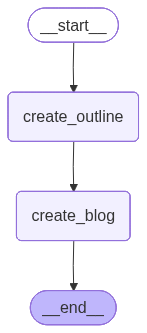

In [37]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [38]:
initial_state = {"prompt": "how to get tech internships in new delhi"}

final_state = workflow.invoke(initial_state)








In [39]:
print(final_state['blog'])

# How to Get Tech Internships in New Delhi

## Introduction

In today's competitive job market, internships play a critical role in shaping one's career, especially in the tech industry. A well-structured internship can provide practical experience, networking opportunities, and a significant boost to your resume. New Delhi, a burgeoning hub for technology and innovation, offers a plethora of internship opportunities for aspiring tech professionals. This blog aims to guide you through the multifaceted landscape of tech internships in New Delhi, equipping you with the tools needed for a successful application and enriching internship experience.

## Section 1: Understanding the Tech Landscape in New Delhi

### 1.1 Overview of the Tech Scene
New Delhi's tech ecosystem has witnessed tremendous growth over the last decade, emerging as a prime destination for startups and established tech companies alike. The city is home to innovation-rich incubators and accelerators like T-Hub and the Acc